<a href="https://colab.research.google.com/github/hamzaqarni1/DeepLearning/blob/main/Tutorial_16/Tutorial_16_GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 404kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.78MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.31MB/s]


Epoch 1/25 | D Loss: 0.0680 | G Loss: 6.0549
Epoch 2/25 | D Loss: 0.0448 | G Loss: 8.4773
Epoch 3/25 | D Loss: 0.2618 | G Loss: 6.4103
Epoch 4/25 | D Loss: 0.7521 | G Loss: 2.6753
Epoch 5/25 | D Loss: 0.5351 | G Loss: 4.3759
Epoch 6/25 | D Loss: 0.4263 | G Loss: 2.6372
Epoch 7/25 | D Loss: 0.7765 | G Loss: 3.4573
Epoch 8/25 | D Loss: 0.5107 | G Loss: 2.1788
Epoch 9/25 | D Loss: 0.4768 | G Loss: 4.1801
Epoch 10/25 | D Loss: 0.3326 | G Loss: 2.7168
Epoch 11/25 | D Loss: 0.5835 | G Loss: 2.4441
Epoch 12/25 | D Loss: 0.5394 | G Loss: 3.8547
Epoch 13/25 | D Loss: 0.2424 | G Loss: 4.7925
Epoch 14/25 | D Loss: 0.7615 | G Loss: 3.3089
Epoch 15/25 | D Loss: 0.6994 | G Loss: 2.7048
Epoch 16/25 | D Loss: 0.4615 | G Loss: 3.0622
Epoch 17/25 | D Loss: 0.5878 | G Loss: 3.7578
Epoch 18/25 | D Loss: 0.4304 | G Loss: 5.4191
Epoch 19/25 | D Loss: 0.3917 | G Loss: 3.4258
Epoch 20/25 | D Loss: 0.3412 | G Loss: 2.6313
Epoch 21/25 | D Loss: 0.4581 | G Loss: 3.0404
Epoch 22/25 | D Loss: 0.2634 | G Loss: 6.83

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

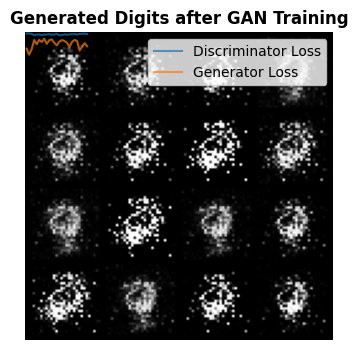

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from google.colab import files

# --- Configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 128
lr = 0.0002
latent_dim = 100
epochs = 25

# --- Dataset: MNIST ---
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# --- Generator & Discriminator ---
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 512), nn.ReLU(),
            nn.Linear(512, 1024), nn.ReLU(),
            nn.Linear(1024, 784), nn.Tanh()
        )
    def forward(self, x): return self.model(x).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 512), nn.LeakyReLU(0.2),
            nn.Linear(512, 256), nn.LeakyReLU(0.2),
            nn.Linear(256, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.model(x)

generator = Generator().to(device)
discriminator = Discriminator().to(device)
opt_g = optim.Adam(generator.parameters(), lr=lr)
opt_d = optim.Adam(discriminator.parameters(), lr=lr)
criterion = nn.BCELoss()

# --- Training Loop with History ---
d_losses, g_losses = [], []
for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(dataloader):
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # Train Discriminator
        opt_d.zero_grad()
        out_real = discriminator(real_imgs)
        loss_d_real = criterion(out_real, torch.ones(b_size, 1).to(device))

        z = torch.randn(b_size, latent_dim).to(device)
        fake_imgs = generator(z)
        out_fake = discriminator(fake_imgs.detach())
        loss_d_fake = criterion(out_fake, torch.zeros(b_size, 1).to(device))

        d_loss = loss_d_real + loss_d_fake
        d_loss.backward(); opt_d.step()

        # Train Generator
        opt_g.zero_grad()
        out_g = discriminator(fake_imgs)
        g_loss = criterion(out_g, torch.ones(b_size, 1).to(device))
        g_loss.backward(); opt_g.step()

    d_losses.append(d_loss.item()); g_losses.append(g_loss.item())
    print(f"Epoch {epoch+1}/{epochs} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

# --- Visual 1: Loss Convergence Plot ---
plt.figure(figsize=(8, 4))
plt.plot(d_losses, label='Discriminator Loss', alpha=0.7)
plt.plot(g_losses, label='Generator Loss', alpha=0.7)
plt.title("GAN Training Convergence", fontweight='bold')
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
plt.savefig("gan_loss.png", dpi=300); files.download("gan_loss.png")

# --- Visual 2: Generated Digits ---
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    grid = torchvision.utils.make_grid(generator(z).cpu(), nrow=4, normalize=True)
    plt.imshow(grid.permute(1, 2, 0))
    plt.title("Generated Digits after GAN Training", fontweight='bold')
    plt.axis('off'); plt.savefig("generated_digits.png", dpi=300); files.download("generated_digits.png")